In [2]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv('diabetes_binary_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [5]:
def overview(df):
    '''
    Erstelle einen Überblick über einige wichtige Eigenschaften der Spalten eines DataFrames.
    VARs
        df: Der zu betrachtende DataFrame
    RETURNS:
        None
    '''
    df = df.copy()
    display(pd.DataFrame({'dtype': df.dtypes,                                   # Dtypes
                          'total': df.count(),                                  # Anzahl valider Einträge
                          'missing_n': df.isna().sum(),                         # Anzahl nan-Einträge
                          'missing_%': df.isna().mean()*100,                    # Anteil fehlender Daten in %
                          'uniques_n': df.nunique(),                            # Kardinalität (Anzahl einzigartiger Werte)
                          'uniques': [df[col].unique() for col in df.columns]   # Auflistung einzigartiger Werte
                         }))
overview(df)

,dtype,total,missing_n,missing_%,uniques_n,uniques
Diabetes_binary,float64,253680,0,0.0,2,"[0.0, 1.0]"
HighBP,float64,253680,0,0.0,2,"[1.0, 0.0]"
HighChol,float64,253680,0,0.0,2,"[1.0, 0.0]"
CholCheck,float64,253680,0,0.0,2,"[1.0, 0.0]"
BMI,float64,253680,0,0.0,84,"[40.0, 25.0, 28.0, 27.0, 24.0, 30.0, 34.0, 26...."
Smoker,float64,253680,0,0.0,2,"[1.0, 0.0]"
Stroke,float64,253680,0,0.0,2,"[0.0, 1.0]"
HeartDiseaseorAttack,float64,253680,0,0.0,2,"[0.0, 1.0]"
PhysActivity,float64,253680,0,0.0,2,"[0.0, 1.0]"
Fruits,float64,253680,0,0.0,2,"[0.0, 1.0]"


* keine fehlenden Werte
* viele binäre Spalten
* nur numerisch kodierte SPalten, die aber umgeformt werden müssen

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,253680.0,0.139333,0.346294,0.0,0.0,0.0,0.0,1.0
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0


<Axes: ylabel='ratio'>

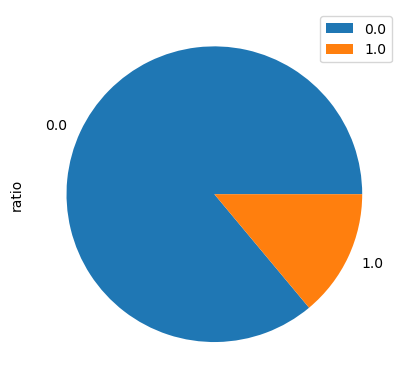

In [8]:
# check for class weights
crosstab = pd.crosstab(index=df['Diabetes_binary'], columns='ratio', normalize=True)
crosstab.plot(kind='pie', y='ratio')